Upload and Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()

# Load the dataset
df = pd.read_csv('brca.csv')

# View the first 2 rows to confirm loading
print("Dataset loaded successfully!")
print(df.head(2))

Saving brca.csv to brca.csv
Dataset loaded successfully!
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1          13.54           14.36             87.46        566.3   
1           2          13.08           15.71             85.63        520.0   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   

   x.concave_pts_mean  x.symmetry_mean  ...  x.texture_worst  \
0             0.04781           0.1885  ...            19.26   
1             0.03110           0.1967  ...            20.49   

   x.perimeter_worst  x.area_worst  x.smoothness_worst  x.compactness_worst  \
0              99.70         711.2              0.1440               0.1773   
1              96.09         630.5              0.1312               0.2776   

   x.concavity_worst  x.concave_pts_worst  x.symmetry_worst  \
0              0.239    

/tmp/ipykernel_4677/3221948830.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[target_column], palette='viridis')


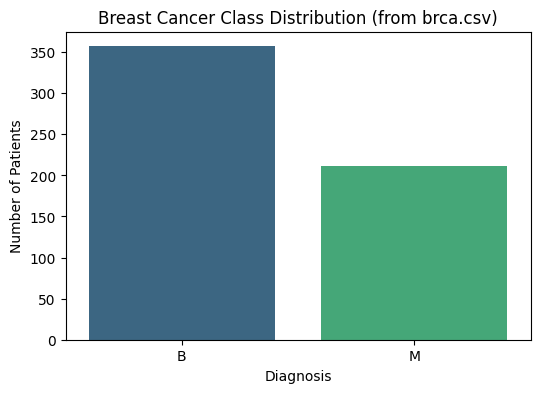

In [ ]:

# 1. Load the dataset directly from your CSV file
df = pd.read_csv('brca.csv')

# Note: If your CSV uses a different name for the output column (like 'diagnosis', 'target', or 'Class'),
# just change the word 'y' below to match your file!
target_column = 'y'

# 2. Generate the visualization
plt.figure(figsize=(6, 4))
sns.countplot(x=df[target_column], palette='viridis')

plt.title('Breast Cancer Class Distribution (from brca.csv)')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')

plt.show()

Data Exploration & Cleaning

In [ ]:
# Check dataset shape and info
print(f"Dataset Shape (Rows, Columns): {df.shape}")

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Drop duplicates if any exist
df = df.drop_duplicates()

# Check for missing values
print("Total missing values:", df.isnull().sum().sum())

Dataset Shape (Rows, Columns): (569, 32)
Duplicate rows: 0
Total missing values: 0


Prepare Features (X) and Target (y)

In [ ]:
# Drop the index column ('Unnamed: 0') and the target column ('y') to isolate the 30 features
X = df.drop(columns=['Unnamed: 0', 'y'])

# Convert target column 'y' into binary numerical values (Malignant 'M' = 1, Benign 'B' = 0)
y = df['y'].map({'M': 1, 'B': 0})

print(f"Features shape (X): {X.shape}") # Should be (569 rows, 30 features)[cite: 1]
print(f"Target shape (y): {y.shape}")

Features shape (X): (569, 30)
Target shape (y): (569,)


Data Visualization

/tmp/ipykernel_1193/336649037.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


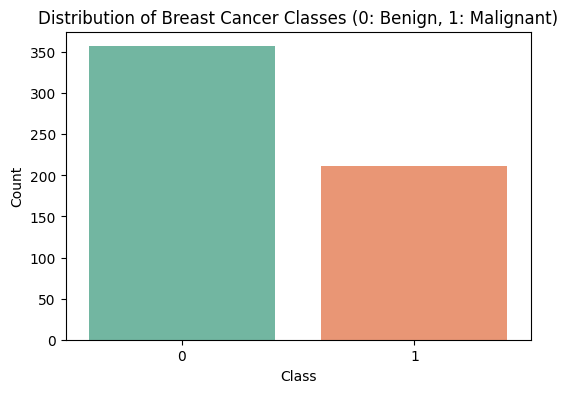

In [ ]:
# Visualize the distribution of Benign (0) vs Malignant (1) classes
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set2')
plt.title("Distribution of Breast Cancer Classes (0: Benign, 1: Malignant)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Preprocessing, Scaling, and Baseline Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply feature scaling (normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train baseline classifier using all 30 features[cite: 1]
baseline_model = KNeighborsClassifier(n_neighbors=5)
baseline_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = baseline_model.predict(X_test_scaled)

Evaluate and Display Baseline Benchmark

In [ ]:
# Calculate evaluation metrics[cite: 1, 2]
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("==================================================")
print("     BASELINE MODEL PERFORMANCE (All 30 Features) ")
print("==================================================")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Total Features Used: {X.shape[1]}")
print("==================================================")

     BASELINE MODEL PERFORMANCE (All 30 Features) 
Accuracy:  0.9298
Precision: 0.9730
Recall:    0.8372
F1-Score:  0.9000
Total Features Used: 30


In [ ]:
# Save processed arrays so your teammates can use the exact same splits
pd.DataFrame(X_train_scaled, columns=X.columns).to_csv('X_train_scaled.csv', index=False)
pd.DataFrame(X_test_scaled, columns=X.columns).to_csv('X_test_scaled.csv', index=False)
pd.Series(y_train).to_csv('y_train.csv', index=False)
pd.Series(y_test).to_csv('y_test.csv', index=False)

# Automatically download the processed files to your computer for easy sharing
files.download('X_train_scaled.csv')
files.download('X_test_scaled.csv')
files.download('y_train.csv')
files.download('y_test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>